# Code → Skill Matcher Playground

Experiment with the tree-sitter → Jina embeddings → FAISS pipeline.

Pipeline:
1. Parse Python source with tree-sitter, extract function/method blocks
2. Strip docstrings, extract raw code
3. Embed each block with `jinaai/jina-embeddings-v2-base-code` (8K context)
4. Query FAISS index of skill label embeddings
5. Aggregate per-block scores into a file-level skill summary

## 1. Setup — Django env + imports

In [3]:
import os, sys

print(f'Python: {sys.executable}')
print(f'CWD:    {os.getcwd()}')

# Must be set before any library loads libomp (torch + faiss-cpu both link it on macOS)
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Jupyter's kernel runs on an asyncio event loop; allow Django's sync ORM from here
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')

BACKEND_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'django', 'backend'))
assert os.path.isfile(os.path.join(BACKEND_DIR, 'manage.py')), (
    f'Expected Django backend at {BACKEND_DIR} — adjust the path above if needed.'
)
if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'backend.settings')

import django
django.setup()

from django.conf import settings
print('Available datasets:', list(settings.SKILL_DATASETS.keys()))

Python: /Users/justinchung/anaconda3/envs/swemap_django/bin/python
CWD:    /Users/justinchung/Code/SWEMAP/data-ingestion/playground
Available datasets: ['cso', 'conda', 'swe_anchor']


In [ ]:
from skill_analysis.services.code_skill_matcher import CodeSkillMatcher
from skill_analysis.services.cso_vectorizer import CSOVectorizer
from skill_analysis.services.embedding import get_encoder, MODEL_NAME

print(f'Encoder model: {MODEL_NAME}')
encoder = get_encoder()
encoder._ensure_loaded()  # triggers model download on first run

Encoder model: jinaai/jina-embeddings-v2-base-code


## 2. Load a FAISS index (pick a dataset)

In [5]:
DATASET = 'swe_anchor'  # 'conda' or 'cso' or 'swe_anchor'

config = settings.SKILL_DATASETS[DATASET]
index, mapping = CSOVectorizer.load(config['index_path'], config['mapping_path'])
matcher = CodeSkillMatcher(index, mapping)

print(f"Loaded '{DATASET}': d={index.d}, ntotal={index.ntotal}")
print(f'First few skills: {[m.rsplit("/", 1)[-1] for m in mapping[:5]]}')

Loaded 'swe_anchor': d=768, ntotal=118
First few skills: ['Algorithms & Logic', 'Backend & API', 'Concurrency & Execution', 'Data & Storage', 'Quality Assurance']


### Pick a file to analyze

In [26]:
FILE_PATH = os.path.abspath(os.path.join(os.getcwd(), 'signals.py'))

with open(FILE_PATH, encoding='utf-8') as f:
    source_code = f.read()

print(f'Loaded {FILE_PATH} ({len(source_code)} chars)')

Loaded /Users/justinchung/Code/SWEMAP/data-ingestion/playground/signals.py (1788 chars)


### Inspect extracted blocks

Tree-sitter extracts top-level functions. Classes are decomposed into their methods so each method is embedded separately.

In [16]:
blocks = matcher.get_code_blocks(source_code)
print(f'Found {len(blocks)} blocks:')
for node, parent_class in blocks:
    name = matcher.get_block_name(node)
    label = f'{parent_class}.{name}' if parent_class else name
    kind = 'method' if parent_class else 'function'
    print(f'  [{kind}] {label}')

Found 2 blocks:
  [function] get_signal_name
  [function] signal_handler


### Preview what will be embedded

See the raw code (docstrings stripped) and check token counts against the model's capacity.

In [8]:
STRIP_DOCSTRINGS = True

encoder = get_encoder()
encoder._ensure_loaded()  # triggers model download on first run
tok = encoder._tokenizer

for node, parent_class in blocks:
    name = matcher.get_block_name(node)
    label = f'{parent_class}.{name}' if parent_class else name
    text = matcher.extract_code(node, strip_docstring=STRIP_DOCSTRINGS)
    n_tokens = len(tok(text, truncation=False)['input_ids'])
    print(f'=== {label} — {len(text)} chars, {n_tokens} tokens ===')
    print(text)
    print()

/Users/justinchung/.cache/huggingface/modules/transformers_modules/jinaai/jina_hyphen_bert_hyphen_v2_hyphen_qk_hyphen_post_hyphen_norm/3baf9e3ac750e76e8edd3019170176884695fb94/configuration_bert.py:29: UserWarning: optimum is not installed. To use OnnxConfig and BertOnnxConfig, make sure that `optimum` package is installed
  warnings.warn("optimum is not installed. To use OnnxConfig and BertOnnxConfig, make sure that `optimum` package is installed")


NameError: name 'blocks' is not defined

### Match blocks to skills

In [18]:
K = 5
MODE = 'raw'  # 'raw' or 'sexpr'

results = matcher.match_file(
    source_code,
    k=K,
    mode=MODE,
    strip_docstrings=STRIP_DOCSTRINGS,
)

for r in results:
    print(f"[{r['block_type']}] {r['block_name']}:")
    for uri, score in r['skills']:
        label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
        print(f'  {label:40s} score={score:.4f}')
    print()

[function] get_signal_name:
  signal                                   score=0.3870
  os.path                                  score=0.2138
  regex                                    score=0.1403
  RQ                                       score=0.1385
  psycopg2                                 score=0.1314

[function] signal_handler:
  signal                                   score=0.4536
  Middleware & Routing                     score=0.3258
  Node.js Event Loop                       score=0.2129
  sinon                                    score=0.1774
  WSGI                                     score=0.1774



### File-level aggregate (max-pool across blocks)

In [8]:
aggregate_max = CodeSkillMatcher.aggregate(results, k=K, pool='max')
aggregate_mean = CodeSkillMatcher.aggregate(results, k=K, pool='mean')

print('--- Max pool ---')
for uri, score in aggregate_max:
    label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
    print(f'  {label:40s} score={score:.4f}')

print('\n--- Mean pool ---')
for uri, score in aggregate_mean:
    label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
    print(f'  {label:40s} score={score:.4f}')

--- Max pool ---
  signal_processing                        score=0.4697
  switching_signals                        score=0.4580
  desired_signal                           score=0.4441
  signal_detection                         score=0.4396
  closed-loop_signals                      score=0.4395

--- Mean pool ---
  signal_processing                        score=0.4697
  switching_signals                        score=0.4580
  desired_signal                           score=0.4441
  signal_detection                         score=0.4396
  closed-loop_signals                      score=0.4395


## Application: Skill Analysis on Engineer
### Get skills per block

In [ ]:
import os
import django
import json

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'backend.settings')
django.setup()

from django.conf import settings
from skill_analysis.services.code_skill_matcher import get_engineer_files, CodeSkillMatcher
from skill_analysis.services.cso_vectorizer import CSOVectorizer # update import if needed

# 1. Provide the absolute root path to where the files live on your drive
REPO_ROOT = "/Users/justinchung/Code/SWEMAP/conda"

if __name__ == '__main__':
    # 4. Get the files for the engineer
    files = get_engineer_files(3424)
    print(f"Found {len(files)} files for engineer. Loading vector index...")
    
    # 5. Initialize the FAISS index just ONCE
    config = settings.SKILL_DATASETS['swe_anchor']
    index, mapping = CSOVectorizer.load(config['index_path'], config['mapping_path'])
    matcher = CodeSkillMatcher(index, mapping)
    
    all_results = []
    total_functions_analyzed = 0
    
    counter = 0
    # 6. Loop through files and analyze
    for rel_path in files:
        if counter == len(files): break
        full_path = os.path.join(REPO_ROOT, rel_path)
        
        # Skip files that might not exist locally
        if not os.path.exists(full_path):
            continue
            
        with open(full_path, 'r', encoding='utf-8', errors='ignore') as f:
            source_code = f.read()
            
        # Run the pipeline to get per-block skills
        # MAKE SURE max_length in code_skill_matcher.py is set back to 512!
        file_results = matcher.match_file(source_code, k=5, mode='raw')
        if file_results:
            counter += 1
            print(counter)
        all_results.extend(file_results)
        total_functions_analyzed += len(file_results)
        
    print(f"\nAnalyzed {total_functions_analyzed} functions across {len(files)} files.")
    
    # 7. Aggregate all blocks across all files for this engineer
    if all_results:
        engineer_top_skills = CodeSkillMatcher.aggregate(all_results, k=10, pool="max")
        print("\n--- Top 10 Aggregated Skills for Engineer ---")
        for uri, score in engineer_top_skills:
            # Clean up the URI for display
            label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
            print(f"  {label:40s} (score={score:.4f})")
            
        # 8. Write the results to a JSON file for later use
        dump_path = '/Users/justinchung/Code/SWEMAP/data-ingestion/playground/engineer_3424_swe_anchor.json'
        with open(dump_path, 'w') as f:                                                         
            json.dump({                                                                         
                'engineer_id': 3424,                                                            
                'dataset': 'swe_anchor',                                                        
                'repo_root': REPO_ROOT,                                                       
                'total_functions_analyzed': total_functions_analyzed,                         
                'per_block': all_results,           
                'top_skills': [{'uri': u, 'score': s} for u, s in engineer_top_skills],         
            }, f, indent=2, ensure_ascii=False)     
        print(f'Wrote {dump_path}') 
    else:
        print("\nNo code functions found to aggregate.")


### Aggregate blocks into skill chains

In [33]:
import json                                                            
from collections import defaultdict                                    
from statistics import mean                                            
                                                                        
in_path = '/Users/justinchung/Code/SWEMAP/data-ingestion/playground/engineer_3424_swe_anchor.json'                                            
tree_path = '/Users/justinchung/Code/SWEMAP/data-ingestion/data/swe_concept_anchors.json'                                                     
out_path = '/Users/justinchung/Code/SWEMAP/data-ingestion/playground/engineer_3424_swe_anchor_aggregated.json'                                
TOP_K = 5                                                              
POOL = 'max'  # how to collapse multiple score hits on the same label  
                                                                        
with open(in_path) as f:                                               
    data = json.load(f)                                                
with open(tree_path) as f:                                             
    tree = json.load(f)                                                
                                                                        
# 1. Collect all score hits per label across blocks.                   
contributions: dict[str, list[float]] = defaultdict(list)              
for block in data['per_block']:                                        
    for skill, score in block['skills']:                               
        contributions[skill].append(score)
                                                                        
def own_score(name: str) -> float:
    scores = contributions.get(name, [])
    if not scores:                                                     
        return 0.0
    return max(scores) if POOL == 'max' else mean(scores)              
                
# 2. Recursively copy the tree, attaching a `score` field (final score)
#    to each node. final(node) = own(node) + avg(final(child) for child).                                                                
def score_subtree(node: dict) -> dict:
    name = node['name']                                                
    own = own_score(name)                                              
    scored_children = [score_subtree(c) for c in node.get('children',
[])]                                                                   
    if scored_children:
        final = own + mean(c['score'] for c in scored_children)        
    else:       
        final = own
    return {'name': name, 'score': final, 'children': scored_children} 

result = {                                                             
    'engineer_id': data.get('engineer_id'),
    'pool': POOL,                                                      
    'roots': [score_subtree(root) for root in tree['roots']],
}                                                                      
                
with open(out_path, 'w') as f:                                         
    json.dump(result, f, indent=2)
                                                                        
print(f'Wrote {out_path}')
for root in result['roots']:
    print(f"  {root['name']}: {root['score']:.4f}")

Wrote /Users/justinchung/Code/SWEMAP/data-ingestion/playground/engineer_3424_swe_anchor_aggregated.json
  Backend & API: 1.2728
  Concurrency & Execution: 1.3332
  Data & Storage: 1.3620
  Systems Programming: 1.4206
  Quality Assurance: 1.5400
  Security & Cryptography: 1.3207
  Algorithms & Logic: 1.4855


In [ ]:
from skill_analysis.services.skill_graph_builder import SkillGraphBuilder               
                                                                                          
graph = SkillGraphBuilder.load(config['graph_path']).graph                              
                                                                                        
def ancestors_chain(g, node):
    """Return [node, parent, grandparent, ...] walking taxonomy edges up."""            
    chain = [node]                          
    seen = {node}                                                                       
    current = node                                        
    while True:                                                                         
        parents = [                                       
            p for p, _, d in g.in_edges(current, data=True)                             
            if d.get('rel_type') == 'taxonomy' and p not in seen
        ]                                   
        if not parents:                 
            break                                                                       
        current = parents[0]  # pick one parent; CSO/conda taxonomy is usually tree-like
        seen.add(current)                                                               
        chain.append(current)                                                           
    return chain                                          
                                                                                        
for uri, score in engineer_top_skills:
    chain = ancestors_chain(graph, uri)                                                 
    labels = [graph.nodes[n].get('label', n) for n in chain]
    print(f"{score:.4f}  " + "  ←  ".join(labels))

0.7176  Topological Sorting  ←  Graph Theory  ←  Algorithm Design
0.7043  os.link / os.symlink  ←  File System Operations  ←  Systems Programming
0.6578  hashlib  ←  Security & Integrity  ←  Systems Programming
0.6516  pycosat / SAT Solving  ←  Constraint Satisfaction  ←  Algorithm Design
0.6306  argparse  ←  Command Line Interfaces (CLI)  ←  Systems Programming
0.5926  Semantic Versioning  ←  Lexical Parsing  ←  Algorithm Design
0.5882  Command Line Interfaces (CLI)  ←  Systems Programming
0.5645  pytest  ←  Testing Frameworks  ←  Quality Assurance & Testing
0.5502  TLS / Proxy Configuration  ←  Network Communication  ←  Backend Development
0.5461  unittest.mock  ←  Mocking & Emulation  ←  Quality Assurance & Testing


In [23]:
import json                                 
                                                                                          
output_path = '/Users/justinchung/Code/SWEMAP/data-ingestion/playground/engineer_skill_chains_241.json'   
                                                                                        
export = {                                                                              
    'engineer_id': 3424,                                                                
    'repo_root': REPO_ROOT,                                                             
    'total_functions_analyzed': total_functions_analyzed, 
    'pool': 'max',                          
    'skills': [                         
        {                                                                               
            'score': round(score, 4),                                                   
            'uri': uri,                                                                 
            'label': graph.nodes[uri].get('label', uri),                                
            'chain': [                                    
                {'uri': n, 'label': graph.nodes[n].get('label', n)}                     
                for n in ancestors_chain(graph, uri)      
            ],                                                                          
        }                               
        for uri, score in engineer_top_skills                                           
    ],                                                                                  
}
                                                                                        
with open(output_path, 'w') as f:                         
    json.dump(export, f, indent=2, ensure_ascii=False)

print(f'Wrote {len(export["skills"])} skill chains to {output_path}')

Wrote 10 skill chains to /Users/justinchung/Code/SWEMAP/data-ingestion/playground/engineer_skill_chains_241.json


## 8. Ad-hoc: query the skill index with arbitrary text

Sanity-check the FAISS index or explore what's in it.

In [ ]:
QUERY = 'register signal handlers for SIGINT and SIGTERM'

hits = CSOVectorizer.query(QUERY, index, mapping, k=10)
print(f"Top-10 skills for: '{QUERY}'")
for uri, score in hits:
    label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
    print(f'  {label:40s} score={score:.4f}')

## 9. Compare `raw` vs `sexpr` on the same file

In [ ]:
raw_results = matcher.match_file(source_code, k=K, mode='raw', strip_docstrings=True)
sexpr_results = matcher.match_file(source_code, k=K, mode='sexpr')

for raw, sexpr in zip(raw_results, sexpr_results):
    print(f"[{raw['block_type']}] {raw['block_name']}")
    print('  raw  :', [uri.rsplit('/', 1)[-1] for uri, _ in raw['skills']])
    print('  sexpr:', [uri.rsplit('/', 1)[-1] for uri, _ in sexpr['skills']])
    print()

# End-to-end

In [ ]:
import os
import json
from collections import defaultdict

import django
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'backend.settings')
django.setup()

from django.conf import settings
from skill_analysis.services.code_skill_matcher import CodeSkillMatcher, get_engineer_files
from skill_analysis.services.cso_vectorizer import CSOVectorizer

# ── Config ──────────────────────────────────────────────────────
ENGINEER_IDS = [3414, 3424, 3476, 3733, 3474, 3421, 3445, 3434, 3428]  # <- Ken Odegard, Jannis Leidel, Sophia Castellarin, Jaime RG, Agriya Khetarpal, Travis Hathaway, Daniel Holth, Mahe Iram Khan, Katherine Kinnaman
REPO_ROOT = '/Users/justinchung/Code/SWEMAP/conda'
DATASET = 'swe_anchor'
TREE_PATH = '/Users/justinchung/Code/SWEMAP/data-ingestion/data/swe_concept_anchors.json'
OUT_DIR = '/Users/justinchung/Code/SWEMAP/data-ingestion/playground'
K = 10           # top-K per block; thresholding will trim, so leave headroom
THRESHOLD = 0.4  # discard matches with similarity below this
DECAY = 0.5      # ancestor at depth d gets DECAY**d per leaf hit


# ── One-time loads ──────────────────────────────────────────────
config = settings.SKILL_DATASETS[DATASET]
index, mapping = CSOVectorizer.load(config['index_path'], config['mapping_path'])
matcher = CodeSkillMatcher(index, mapping)
print(f"Loaded '{DATASET}' index: d={index.d}, ntotal={index.ntotal}")

with open(TREE_PATH) as f:
    tree = json.load(f)

# Build name → parent map once; every engineer reuses it.
parent_of: dict[str, str | None] = {}
def _index_tree(node: dict, parent: str | None) -> None:
    parent_of[node['name']] = parent
    for c in node.get('children', []):
        _index_tree(c, node['name'])
for root in tree['roots']:
    _index_tree(root, None)

def ancestors(name: str) -> list[str]:
    """Return [parent, grandparent, ...] for the given node."""
    chain: list[str] = []
    cur = parent_of.get(name)
    while cur is not None:
        chain.append(cur)
        cur = parent_of.get(cur)
    return chain


# ── Per-engineer pipeline ───────────────────────────────────────
def match_engineer(engineer_id: int) -> list[dict]:
    """Run the code→skill matcher over every file owned by the engineer."""
    files = get_engineer_files(engineer_id)
    print(f"  engineer {engineer_id}: {len(files)} files")
    per_block: list[dict] = []
    for rel_path in files:
        full_path = os.path.join(REPO_ROOT, rel_path)
        if not os.path.exists(full_path):
            continue
        with open(full_path, encoding='utf-8', errors='ignore') as f:
            source_code = f.read()
        per_block.extend(matcher.match_file(source_code, k=K, mode='raw'))
    print(f"  engineer {engineer_id}: analyzed {len(per_block)} blocks")
    return per_block


def score_tree_for(per_block: list[dict]) -> list[dict]:
    """Threshold + decayed-ancestor frequency counting.

    For each block, discard matches with sim < THRESHOLD. Each surviving
    (skill, sim) credits: skill += 1.0, parent += DECAY, grandparent +=
    DECAY**2, etc. Final node score = total accumulated count (raw)."""
    counts: dict[str, float] = defaultdict(float)
    for block in per_block:
        for skill, sim in block['skills']:
            if sim < THRESHOLD or skill not in parent_of:
                continue
            counts[skill] += 1.0
            for depth, ancestor in enumerate(ancestors(skill), start=1):
                counts[ancestor] += DECAY ** depth

    def score_subtree(node: dict) -> dict:
        return {
            'name': node['name'],
            'score': counts.get(node['name'], 0.0),
            'children': [score_subtree(c) for c in node.get('children', [])],
        }

    return [score_subtree(root) for root in tree['roots']]


def run(engineer_ids: list[int]) -> None:
    os.makedirs(OUT_DIR, exist_ok=True)
    for eid in engineer_ids:
        print(f"\n=== Engineer {eid} ===")
        per_block = match_engineer(eid)
        if not per_block:
            print(f"  engineer {eid}: no blocks matched, skipping")
            continue

        result = {
            'engineer_id': eid,
            'dataset': DATASET,
            'repo_root': REPO_ROOT,
            'total_functions_analyzed': len(per_block),
            'top_k': K,
            'threshold': THRESHOLD,
            'decay': DECAY,
            'roots': score_tree_for(per_block),
        }
        out_path = os.path.join(OUT_DIR, f'engineer_{eid}_swe_anchor_aggregated.json')
        with open(out_path, 'w') as f:
            json.dump(result, f, indent=2, ensure_ascii=False)
        print(f"  wrote {out_path}")
        for root in result['roots']:
            print(f"    {root['name']}: {root['score']:.2f}")


run(ENGINEER_IDS)


## 10. Match a GitHub ticket to skills

Fetches issue title + body + comments via REST and embeds the concatenated text directly (skips the AST path — tickets are prose, not code). One vector → FAISS top-K against the index loaded above.

Set `GITHUB_TOKEN` in your env for higher rate limits / private repos. Public conda issues work without one.

In [6]:
import os
import re
import requests
from urllib.parse import urlparse, parse_qs, unquote

GITHUB_TOKEN = os.getenv('GITHUB_TOKEN')


def parse_github_url(url: str) -> tuple[str, str, int]:
    """Accept either a github.com/.../issues/N URL or the projects pane URL
    (?issue=owner|repo|number)."""
    parsed = urlparse(url)
    qs = parse_qs(parsed.query)
    if 'issue' in qs:
        owner, repo, num = unquote(qs['issue'][0]).split('|')
        return owner, repo, int(num)
    m = re.match(r'^/([^/]+)/([^/]+)/issues/(\d+)', parsed.path)
    if m:
        return m.group(1), m.group(2), int(m.group(3))
    raise ValueError(f"Can't parse owner/repo/number from {url!r}")


def fetch_issue_text(owner: str, repo: str, number: int, include_comments: bool = True) -> str:
    """Concatenate title + labels + body + comments into one string."""
    headers = {'Accept': 'application/vnd.github+json'}
    if GITHUB_TOKEN:
        headers['Authorization'] = f'Bearer {GITHUB_TOKEN}'

    base = f'https://api.github.com/repos/{owner}/{repo}/issues/{number}'
    r = requests.get(base, headers=headers, timeout=30)
    r.raise_for_status()
    issue = r.json()

    parts = [f"# {issue['title']}"]
    labels = [l['name'] for l in issue.get('labels', [])]
    if labels:
        parts.append(f"Labels: {', '.join(labels)}")
    parts.append(issue.get('body') or '')

    if include_comments:
        cr = requests.get(f'{base}/comments', headers=headers, timeout=30, params={'per_page': 100})
        cr.raise_for_status()
        for c in cr.json():
            parts.append(f"--- comment by {c['user']['login']} ---")
            parts.append(c.get('body') or '')
            print(f"{c}\n")

    return '\n\n'.join(p for p in parts if p)


TICKET_URL = 'https://github.com/orgs/conda/projects/22/views/10?pane=issue&itemId=178936889&issue=conda%7Cconda-build%7C5122'

owner, repo, number = parse_github_url(TICKET_URL)
print(f'Fetching {owner}/{repo}#{number}...')
ticket_text = fetch_issue_text(owner, repo, number)
print(f'Fetched {len(ticket_text)} chars\n---')
# print(ticket_text[:800] + ('...' if len(ticket_text) > 800 else ''))

Fetching conda/conda-build#5122...
{'url': 'https://api.github.com/repos/conda/conda-build/issues/comments/1945921240', 'html_url': 'https://github.com/conda/conda-build/issues/5122#issuecomment-1945921240', 'issue_url': 'https://api.github.com/repos/conda/conda-build/issues/5122', 'id': 1945921240, 'node_id': 'IC_kwDOAPRE585z_GbY', 'user': {'login': 'adriendelsalle', 'id': 27348745, 'node_id': 'MDQ6VXNlcjI3MzQ4NzQ1', 'avatar_url': 'https://avatars.githubusercontent.com/u/27348745?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/adriendelsalle', 'html_url': 'https://github.com/adriendelsalle', 'followers_url': 'https://api.github.com/users/adriendelsalle/followers', 'following_url': 'https://api.github.com/users/adriendelsalle/following{/other_user}', 'gists_url': 'https://api.github.com/users/adriendelsalle/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/adriendelsalle/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/adriendelsall

In [12]:
# Embed the whole ticket as one vector and query the loaded FAISS index.
# Depends on `encoder`, `index`, `mapping` from cells above.
TICKET_K = 10
TICKET_MAX_LENGTH = 2048  # tokens — encoder supports up to 8192

encoder._ensure_loaded()
tok = encoder._tokenizer

n_tokens = len(tok(ticket_text, truncation=False)['input_ids'])
flag = ' [TRUNCATED]' if n_tokens > TICKET_MAX_LENGTH else ''
print(f'Ticket tokens: {n_tokens} (cap={TICKET_MAX_LENGTH}){flag}')

vec = encoder.encode_single(ticket_text, max_length=TICKET_MAX_LENGTH)
scores, indices = index.search(vec, TICKET_K)

print(f"\nTop-{TICKET_K} skills for {owner}/{repo}#{number}:")
for score, idx in zip(scores[0], indices[0]):
    if idx < 0:
        continue
    uri = mapping[idx]
    label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
    print(f'  {label:40s} score={float(score):.4f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (9932 > 8192). Running this sequence through the model will result in indexing errors


Ticket tokens: 9932 (cap=2048) [TRUNCATED]

Top-10 skills for conda/conda-build#5122:
  PyNaCl                                   score=0.2759
  aiofiles                                 score=0.2480
  pycosat                                  score=0.2394
  pytest                                   score=0.1901
  Spring Boot                              score=0.1862
  networkx                                 score=0.1722
  Quality Assurance                        score=0.1582
  Systems Programming                      score=0.1562
  aiohttp                                  score=0.1500
  shutil                                   score=0.1420


### Match tickets to engineers (weighted top-5)

For each ticket URL: embed the issue text, take the top-5 FAISS skills, then score every engineer's `engineer_<id>_swe_anchor_aggregated.json` as `1.0*S1 + 0.8*S2 + 0.6*S3 + 0.4*S4 + 0.2*S5` and pick the highest. Depends on `encoder`, `index`, `mapping`, `parse_github_url`, `fetch_issue_text` from earlier cells.

In [16]:
import os, json, glob

# ── Config ──────────────────────────────────────────────────────
TICKET_URLS = [
    # Add your ticket URLs here
    'https://github.com/orgs/conda/projects/22/views/11?pane=issue&itemId=148764425&issue=conda%7Cconda%7C15576',
    'https://github.com/orgs/conda/projects/22/views/11?pane=issue&itemId=166450460&issue=conda%7Cconda-pypi%7C278',
    'https://github.com/orgs/conda/projects/22/views/11?pane=issue&itemId=184038986&issue=conda%7Cconda-pypi%7C348',
    'https://github.com/orgs/conda/projects/22/views/11?pane=issue&itemId=162268887&issue=conda%7Cconda%7C15759',
    'https://github.com/orgs/conda/projects/22/views/11?pane=issue&itemId=184120320&issue=conda%7Cconda%7C16036'
]
ENGINEER_DIR = '/Users/justinchung/Code/SWEMAP/data-ingestion/playground'
TOP_N_SKILLS = 5
TICKET_MAX_LENGTH = 2048  # tokens; encoder caps at 8192

ID_TO_NAME = {
    3414: "Ken Odegard",
    3424: "Jannis Leidel",
    3476: "Sophia Castellarin",
    3733: "Jaime RG",
    3474: "Agriya Khetarpal",
    3421: "Travis Hathaway",
    3445: "Daniel Holth",
    3434: "Mahe Iram Khan",
    3428: "Katherine Kinnaman"
}


# ── Load engineer skill maps once ───────────────────────────────
def flatten_tree(roots: list[dict]) -> dict[str, float]:
    """Flatten an aggregated engineer tree into {node_name: score}."""
    out: dict[str, float] = {}
    def walk(node: dict) -> None:
        out[node['name']] = float(node.get('score', 0.0))
        for c in node.get('children', []):
            walk(c)
    for r in roots:
        walk(r)
    return out

engineer_skills: dict[int, dict[str, float]] = {}
for path in sorted(glob.glob(os.path.join(ENGINEER_DIR, 'engineer_*_swe_anchor_aggregated.json'))):
    with open(path) as f:
        data = json.load(f)
    engineer_skills[data['engineer_id']] = flatten_tree(data['roots'])
print(f'Loaded skill maps for {len(engineer_skills)} engineers: {sorted(engineer_skills)}')


# ── Pipeline helpers ────────────────────────────────────────────
def ticket_top_skills(text: str, k: int = TOP_N_SKILLS) -> list[tuple[str, float]]:
    """Embed ticket text and return [(skill_label, faiss_score), ...] in descending score."""
    vec = encoder.encode_single(text, max_length=TICKET_MAX_LENGTH)
    sims, idxs = index.search(vec, k)
    out: list[tuple[str, float]] = []
    for sim, i in zip(sims[0], idxs[0]):
        if i < 0:
            continue
        uri = mapping[i]
        label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
        out.append((label, float(sim)))
    return out


def rank_engineers(top_skills: list[tuple[str, float]]) -> list[dict]:
    """Score = sum over top skills of (ticket_importance * engineer_skill_score)."""
    rows: list[dict] = []
    for eid, smap in engineer_skills.items():
        breakdown = []
        total = 0.0
        for label, importance in top_skills:
            es = smap.get(label, 0.0)
            contrib = importance * es
            total += contrib
            breakdown.append({'skill': label, 'importance': importance, 'eng_score': es, 'contrib': contrib})
        rows.append({'engineer_id': eid, 'weighted_score': total, 'breakdown': breakdown})
    rows.sort(key=lambda r: r['weighted_score'], reverse=True)
    return rows


# ── Run over every ticket ───────────────────────────────────────
match_results: list[dict] = []
for url in TICKET_URLS:
    owner, repo, number = parse_github_url(url)
    ticket_id = f'{owner}/{repo}#{number}'
    print(f'\n=== {ticket_id} ===')

    text = fetch_issue_text(owner, repo, number)
    top = ticket_top_skills(text)
    print('Top-5 required skills:')
    for label, sim in top:
        print(f'  {label:40s} faiss={sim:.4f}')

    if len(top) < TOP_N_SKILLS:
        print(f'  WARN: only {len(top)} skills returned (expected {TOP_N_SKILLS})')

    ranked = rank_engineers(top)
    best = ranked[0]
    engineer_name = ID_TO_NAME.get(best['engineer_id'], f'Engineer {best["engineer_id"]}')
    print(f'\nBest match: {engineer_name}  weighted={best["weighted_score"]:.4f}')
    print('Full ranking:')
    for r in ranked:
        engineer_name = ID_TO_NAME.get(r['engineer_id'], f'Engineer {r["engineer_id"]}')
        print(f'  {engineer_name}: {r["weighted_score"]:.4f}')
    print('Winner breakdown:')
    for b in best['breakdown']:
        print(f'  {b["skill"]:40s} importance={b["importance"]:.4f}  eng_score={b["eng_score"]:.4f}  contrib={b["contrib"]:.4f}')

    match_results.append({
        'ticket': ticket_id,
        'top_skills': top,
        'ranking': ranked,
    })

print('\n--- Summary ---')
for r in match_results:
    best = r['ranking'][0]
    engineer_name = ID_TO_NAME.get(best['engineer_id'], f'Engineer {best["engineer_id"]}')
    print(f'  {r["ticket"]:40s} -> {engineer_name}  ({best["weighted_score"]:.4f})')


Loaded skill maps for 8 engineers: [3414, 3421, 3424, 3428, 3434, 3445, 3474, 3476]

=== conda/conda#15576 ===
Top-5 required skills:
  PyNaCl                                   faiss=0.2663
  Shell & CLI Applications                 faiss=0.2265
  pytest                                   faiss=0.2166
  pycosat                                  faiss=0.2070
  yaml                                     faiss=0.1990

Best match: Travis Hathaway  weighted=121.9641
Full ranking:
  Travis Hathaway: 121.9641
  Ken Odegard: 101.7888
  Jannis Leidel: 59.6562
  Sophia Castellarin: 53.2941
  Daniel Holth: 46.2821
  Agriya Khetarpal: 45.2766
  Mahe Iram Khan: 15.9123
  Katherine Kinnaman: 0.8962
Winner breakdown:
  PyNaCl                                   importance=0.2663  eng_score=0.0000  contrib=0.0000
  Shell & CLI Applications                 importance=0.2265  eng_score=137.5000  contrib=31.1490
  pytest                                   importance=0.2166  eng_score=399.0000  contrib=86.4286
 

## Data Analysis

Loaded 8 engineers: [3414, 3421, 3424, 3428, 3434, 3445, 3474, 3476]


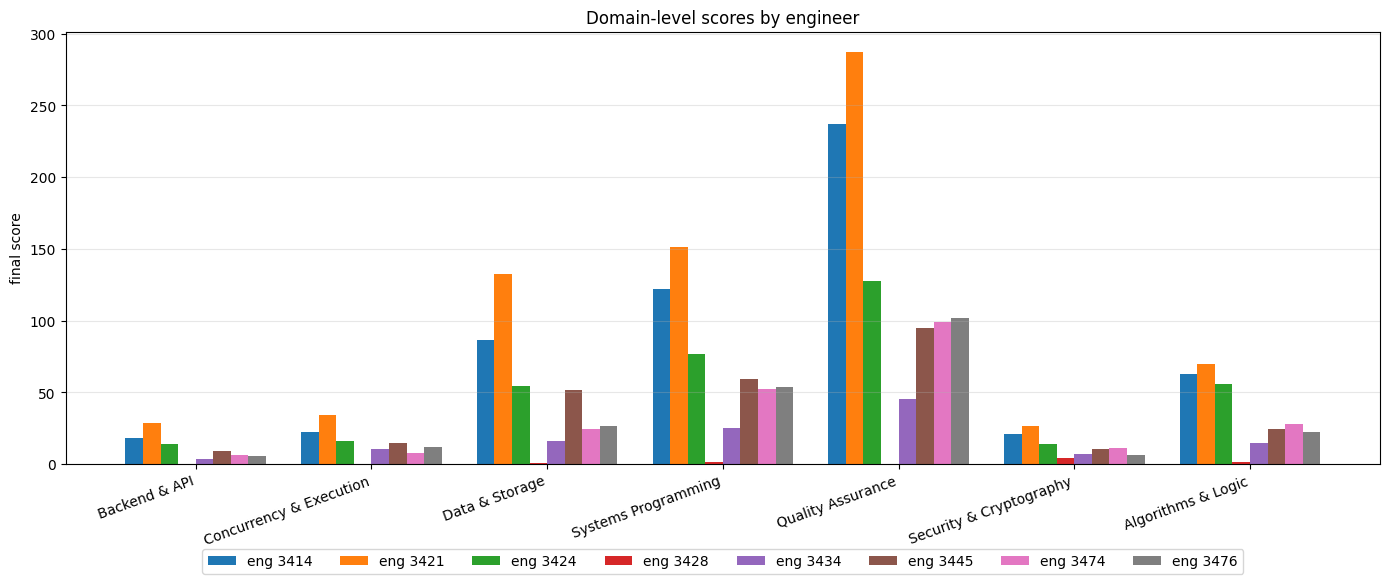

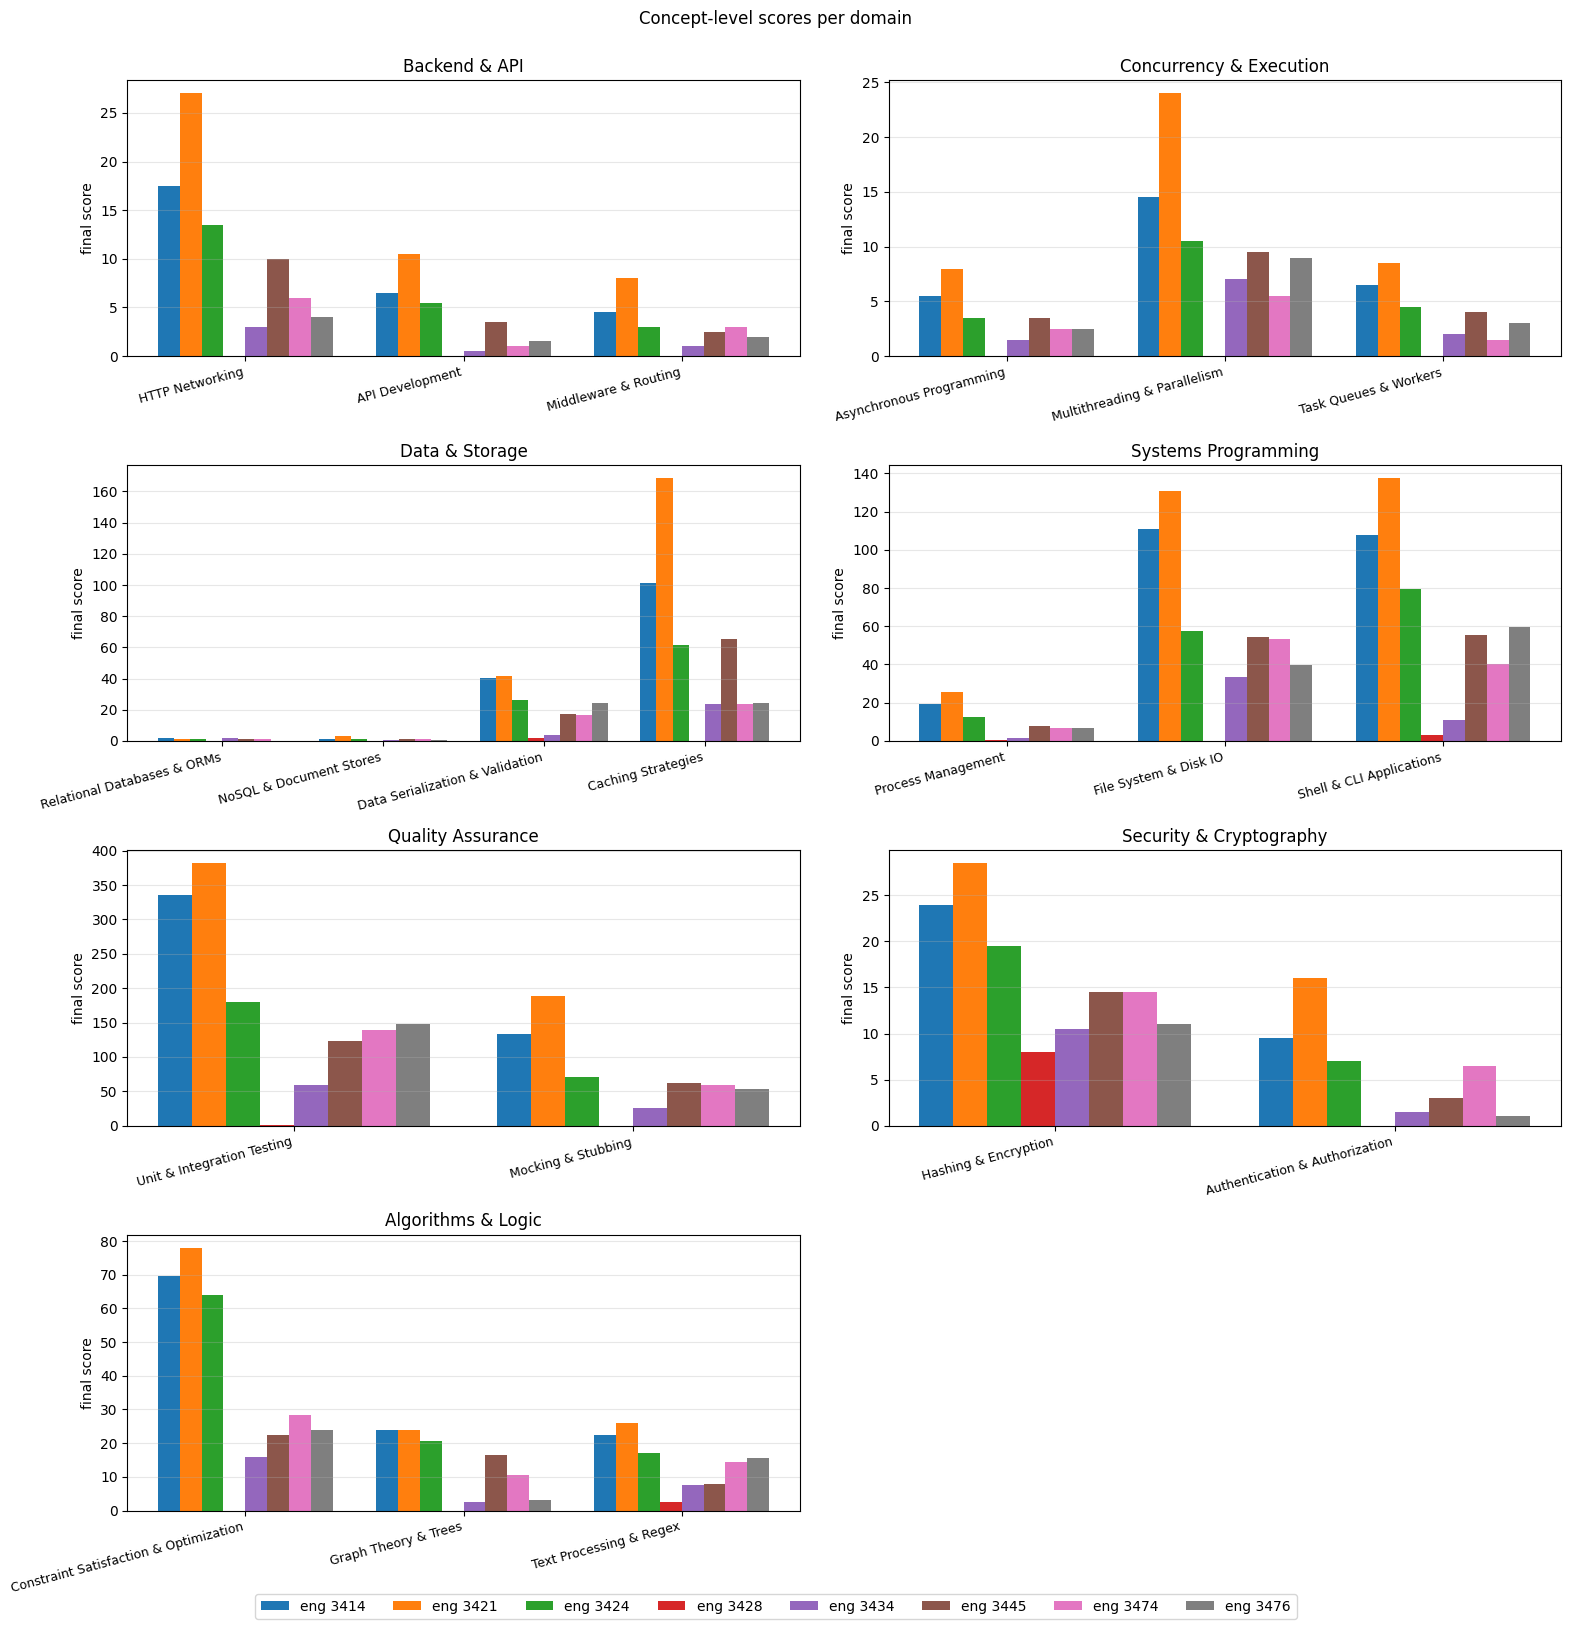

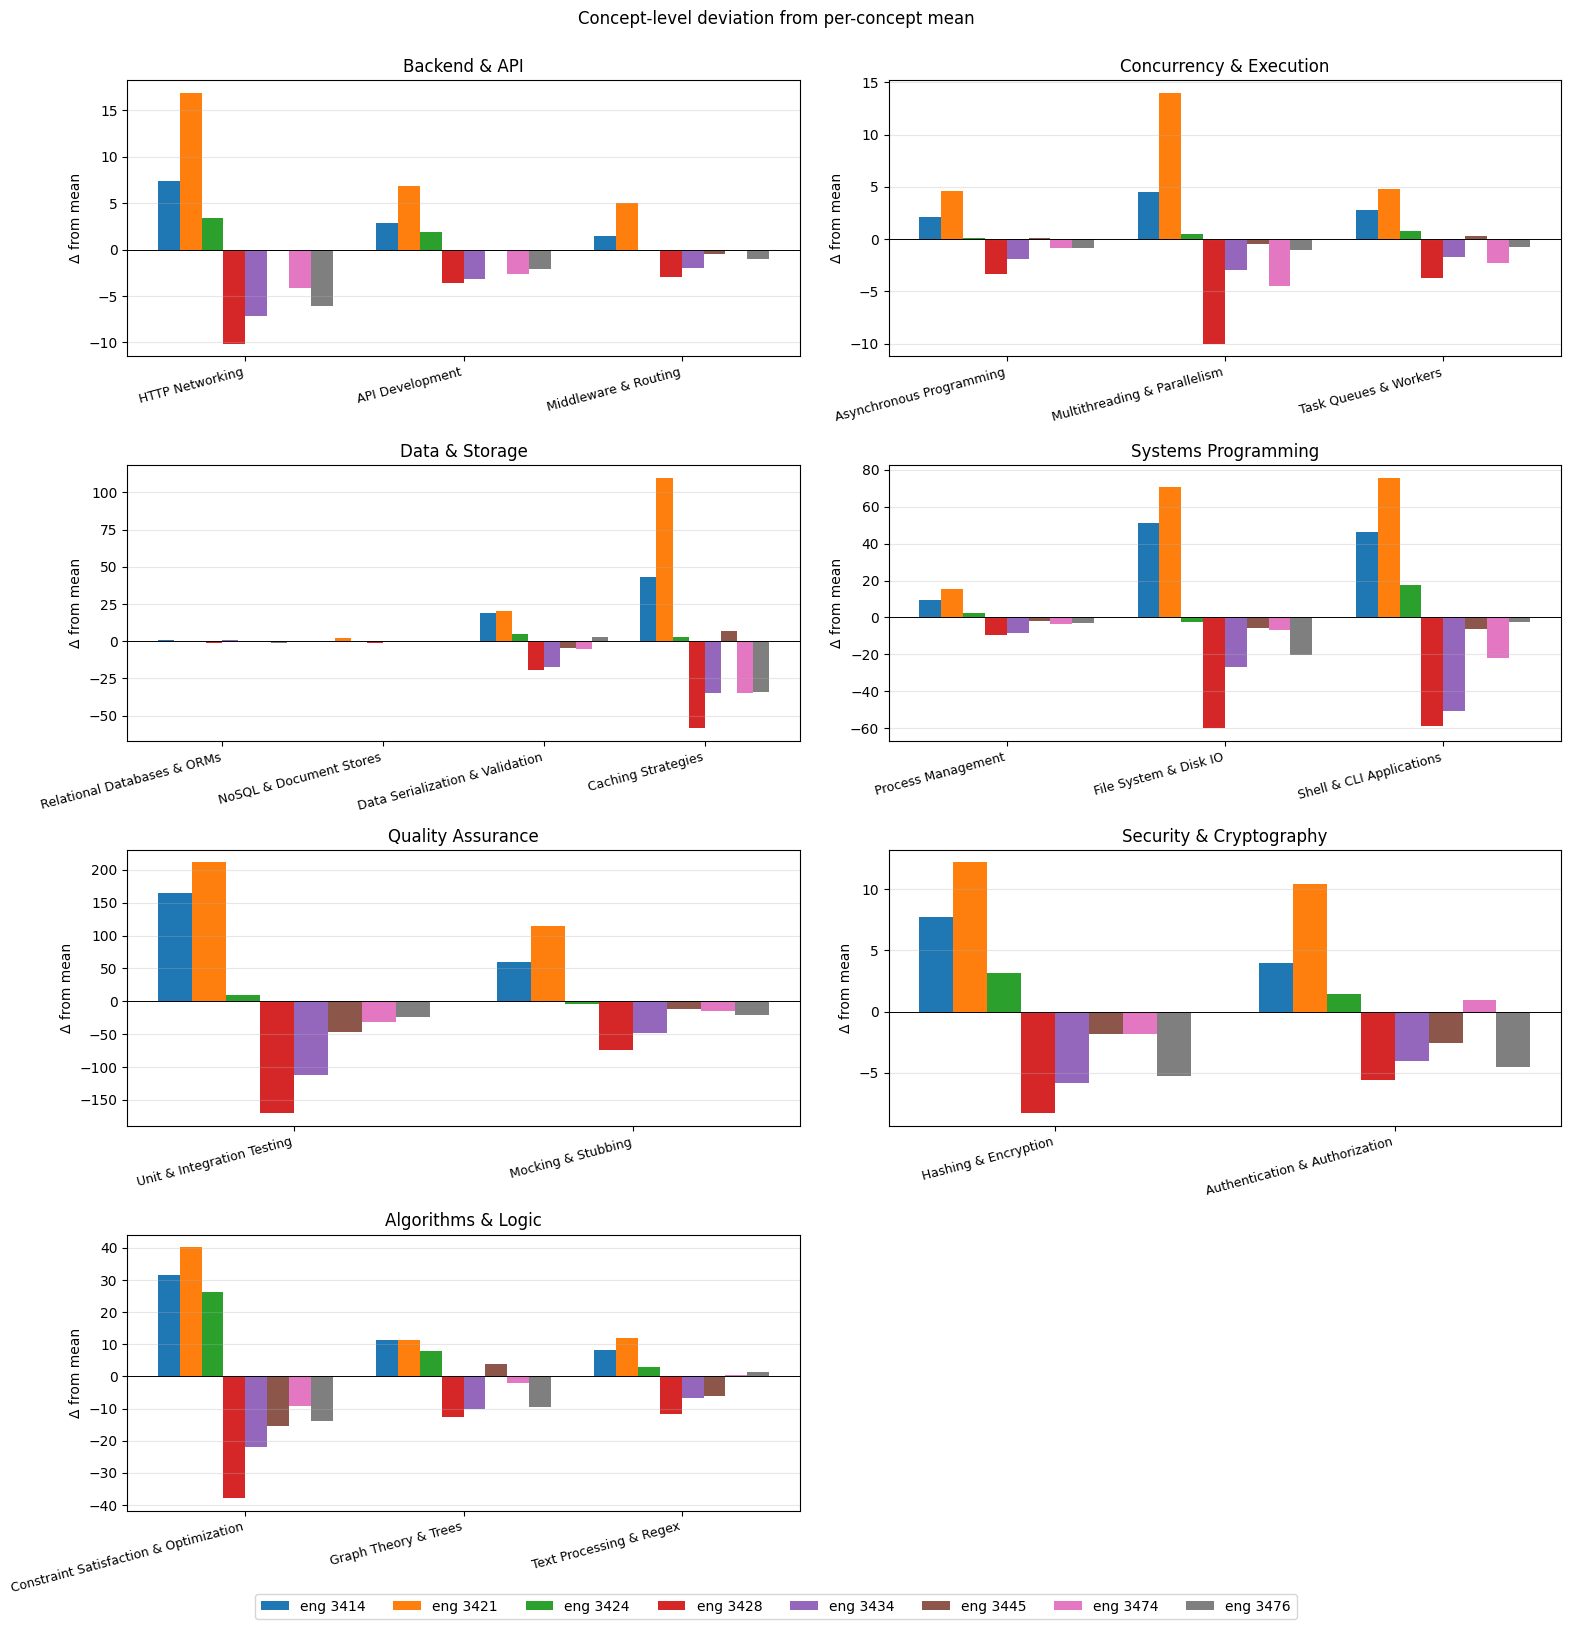

In [46]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PLAYGROUND_DIR = Path('/Users/justinchung/Code/SWEMAP/data-ingestion/playground')

# ── Load every aggregated engineer file in playground/ ──────────
engineer_data: dict[int, dict] = {}
for path in sorted(PLAYGROUND_DIR.glob('engineer_*_swe_anchor_aggregated.json')):
    eid = int(path.stem.split('_')[1])
    engineer_data[eid] = json.load(open(path))

engineer_ids = sorted(engineer_data.keys())
print(f'Loaded {len(engineer_ids)} engineers: {engineer_ids}')

# All engineers share the same anchor tree shape — pull domains/concepts from one.
sample_roots = engineer_data[engineer_ids[0]]['roots']
domains = [r['name'] for r in sample_roots]
concepts_by_domain = {r['name']: [c['name'] for c in r['children']] for r in sample_roots}

def score_lookup(roots: list[dict]) -> dict[tuple[str, str | None], float]:
    """Flatten {(domain, concept_or_None): score}. None-concept = the domain's own score."""
    out: dict[tuple[str, str | None], float] = {}
    for d in roots:
        out[(d['name'], None)] = d['score']
        for c in d['children']:
            out[(d['name'], c['name'])] = c['score']
    return out

scores = {eid: score_lookup(engineer_data[eid]['roots']) for eid in engineer_ids}

# Distinct color per engineer.
cmap = plt.get_cmap('tab10')
engineer_colors = {eid: cmap(i) for i, eid in enumerate(engineer_ids)}
n_eng = len(engineer_ids)
bar_width = 0.8 / n_eng

# ── Figure 1: domain-level grouped bars ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(domains))
for i, eid in enumerate(engineer_ids):
    vals = [scores[eid][(d, None)] for d in domains]
    ax.bar(x + i * bar_width, vals, bar_width, label=f'eng {eid}', color=engineer_colors[eid])
ax.set_xticks(x + (n_eng - 1) * bar_width / 2)
ax.set_xticklabels(domains, rotation=20, ha='right')
ax.set_ylabel('final score')
ax.set_title('Domain-level scores by engineer')
ax.legend(ncol=n_eng, loc='upper center', bbox_to_anchor=(0.5, -0.18))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figure 2: per-domain concept bars (small multiples) ─────────
ncols = 2
nrows = (len(domains) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()
for ax_idx, domain in enumerate(domains):
    ax = axes[ax_idx]
    concepts = concepts_by_domain[domain]
    x = np.arange(len(concepts))
    for i, eid in enumerate(engineer_ids):
        vals = [scores[eid].get((domain, c), 0.0) for c in concepts]
        ax.bar(x + i * bar_width, vals, bar_width, label=f'eng {eid}', color=engineer_colors[eid])
    ax.set_xticks(x + (n_eng - 1) * bar_width / 2)
    ax.set_xticklabels(concepts, rotation=15, ha='right', fontsize=9)
    ax.set_title(domain)
    ax.set_ylabel('final score')
    ax.grid(axis='y', alpha=0.3)
for j in range(len(domains), len(axes)):
    axes[j].set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_eng, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Concept-level scores per domain', y=1.0)
plt.tight_layout()
plt.show()

# ── Figure 3: concept-level deviation from per-concept mean ─────
# Sharpens the comparison when absolute scores cluster (your "everyone is 0.4+" concern).
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()
for ax_idx, domain in enumerate(domains):
    ax = axes[ax_idx]
    concepts = concepts_by_domain[domain]
    x = np.arange(len(concepts))
    means = np.array([
        np.mean([scores[eid].get((domain, c), 0.0) for eid in engineer_ids])
        for c in concepts
    ])
    for i, eid in enumerate(engineer_ids):
        vals = np.array([scores[eid].get((domain, c), 0.0) for c in concepts]) - means
        ax.bar(x + i * bar_width, vals, bar_width, label=f'eng {eid}', color=engineer_colors[eid])
    ax.axhline(0, color='black', lw=0.7)
    ax.set_xticks(x + (n_eng - 1) * bar_width / 2)
    ax.set_xticklabels(concepts, rotation=15, ha='right', fontsize=9)
    ax.set_title(domain)
    ax.set_ylabel('Δ from mean')
    ax.grid(axis='y', alpha=0.3)
for j in range(len(domains), len(axes)):
    axes[j].set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_eng, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Concept-level deviation from per-concept mean', y=1.0)
plt.tight_layout()
plt.show()


In [ ]:
# Embed the whole ticket as one vector and query the loaded FAISS index.
# Depends on `encoder`, `index`, `mapping` from cells above.
TICKET_K = 10
TICKET_MAX_LENGTH = 2048  # tokens — encoder supports up to 8192

encoder._ensure_loaded()
tok = encoder._tokenizer

n_tokens = len(tok(ticket_text, truncation=False)['input_ids'])
flag = ' [TRUNCATED]' if n_tokens > TICKET_MAX_LENGTH else ''
print(f'Ticket tokens: {n_tokens} (cap={TICKET_MAX_LENGTH}){flag}')

vec = encoder.encode_single(ticket_text, max_length=TICKET_MAX_LENGTH)
scores, indices = index.search(vec, TICKET_K)

print(f"\nTop-{TICKET_K} skills for {owner}/{repo}#{number}:")
for score, idx in zip(scores[0], indices[0]):
    if idx < 0:
        continue
    uri = mapping[idx]
    label = uri.rsplit('/', 1)[-1] if '/' in uri else uri
    print(f'  {label:40s} score={float(score):.4f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (9932 > 8192). Running this sequence through the model will result in indexing errors


Ticket tokens: 9932 (cap=2048) [TRUNCATED]

Top-10 skills for conda/conda-build#5122:
  PyNaCl                                   score=0.2759
  aiofiles                                 score=0.2480
  pycosat                                  score=0.2394
  pytest                                   score=0.1901
  Spring Boot                              score=0.1862
  networkx                                 score=0.1722
  Quality Assurance                        score=0.1582
  Systems Programming                      score=0.1562
  aiohttp                                  score=0.1500
  shutil                                   score=0.1420
